# Adult dataset: initial EDA

This notebook loads and explores the Adult dataset from the UCI Machine Learning Repository.

According to the dataset documentation, the table contains both numerical and categorical features, with `income` as the target variable. Missing values in the raw data are marked with `?`, so they are converted to `NaN` during loading. Since the file is comma-separated and contains spaces after commas, `skipinitialspace=True` is used to clean the values at read time.

In [ ]:
import pandas as pd

columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

df = pd.read_csv(url, header=None, names=columns, na_values="?", skipinitialspace=True)

df.head()

In [ ]:
df.info()

## Dataset overview

The dataset contains **32,561 rows** and **15 columns**.

It includes:
- **6 numerical columns**
- **7 multi-class categorical columns**
- **2 binary categorical columns** (`sex` and `income`)

The first 14 columns are input features, while the last column, `income`, is the target variable.

## Missing values

According to the dataset documentation, missing values are expected in the following columns:
- `workclass`
- `occupation`
- `native_country`

The next step is to verify this directly in the loaded dataset and quantify the amount of missing data in each column.

In [ ]:
for col in columns:
    print('Number of missing values at column titled as', col, ':', df[col].isna().sum(), 'Percentage:', df[col].isna().mean() * 100, '%')

The missing values are concentrated in three columns:

- `workclass`: **1,836** missing values (**5.64%**)
- `occupation`: **1,843** missing values (**5.66%**)
- `native_country`: **583** missing values (**1.79%**)

All other columns are complete.

This is an important preprocessing issue, since some synthetic tabular data generation methods may not handle missing values directly. Depending on the selected baseline, these values may need to be imputed, encoded as a separate category, or removed during preprocessing.

In [ ]:
df.describe()

## Numerical columns

The numerical summary shows that the main continuous or count-based variables have plausible ranges.

A few initial observations:
- `age` ranges from **17** to **90**, which is reasonable for this dataset.
- `education_num` ranges from **1** to **16**, matching the ordinal nature of education level.
- `capital_gain` and `capital_loss` are highly skewed, with many zero values.
- `hours_per_week` ranges from **1** to **99**, indicating substantial variation in working hours.

At this stage, there are no obvious invalid negative values in the numerical columns, but the distributions of some variables may still require closer inspection through visualization.

In [ ]:
categ = ["workclass", "education",
    "marital_status", "occupation", "relationship", "race", "sex",
    "native_country", "income"]

for cat in categ:
    print("List of attributes of category titled as", cat, ":", df[cat].unique())

for cat in categ:
    print(df[cat].value_counts(dropna=False).head(10))

## Sensitive attributes

The main sensitive attributes in this dataset are:
- `sex`
- `race`
- potentially `native_country`

These attributes are important because they are related to fairness and representation. If some groups are much smaller than others, a synthetic data generator may reproduce or even amplify these imbalances.

Initial observations:
- `sex` is imbalanced, with more **Male** than **Female** records.
- `race` is strongly dominated by the **White** category, while the other racial groups are much smaller.
- `native_country` is highly concentrated in **United-States**, with most other countries appearing rarely.

These patterns should be considered later when evaluating whether the synthetic data preserves minority groups appropriately.

## Target variable

The target column, `income`, is imbalanced.

- **<=50K**: 24,720 rows
- **>50K**: 7,841 rows

This means that the lower-income class is much more common than the higher-income class. This class imbalance is important for both modeling and evaluation, since a synthetic data generator should preserve the target distribution without collapsing minority patterns.

In [ ]:
df.duplicated().sum()

## Duplicate rows

A check for exact duplicate rows shows that the dataset contains **24 duplicated records**.

This is a very small portion of the full dataset, so duplicates do not appear to be a major issue at this stage. However, they should still be noted, since keeping or removing them may slightly affect preprocessing and model training later.

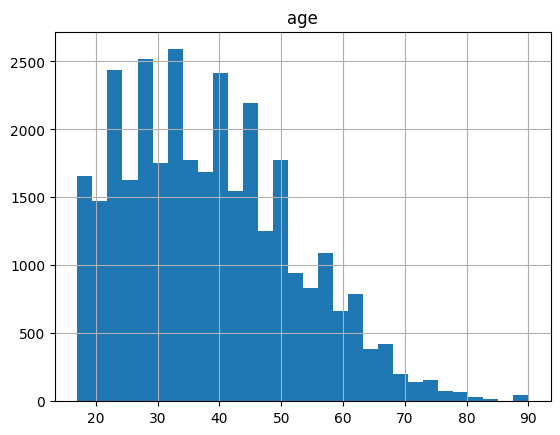

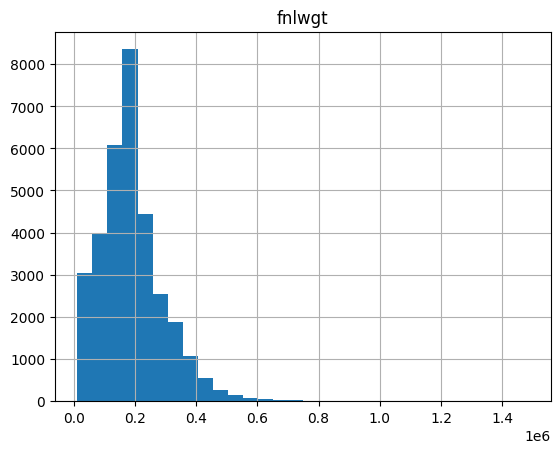

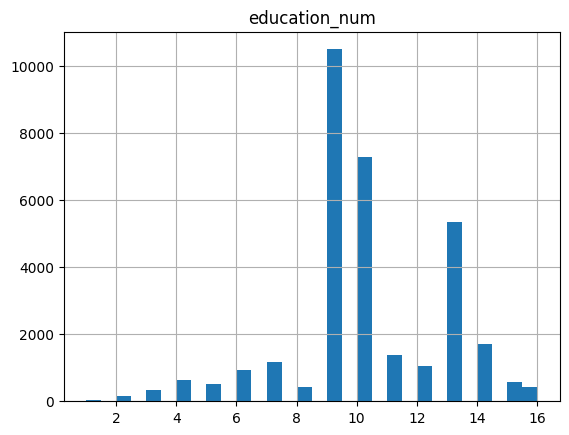

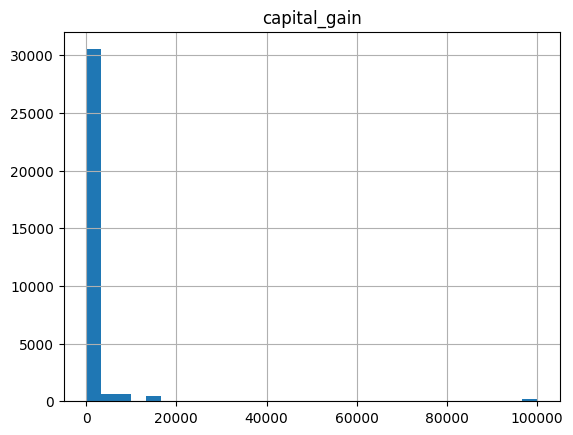

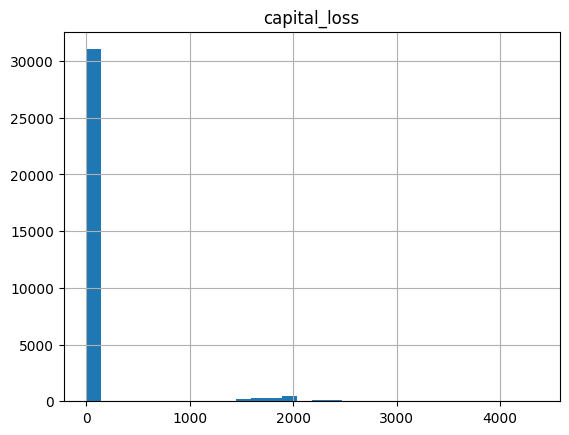

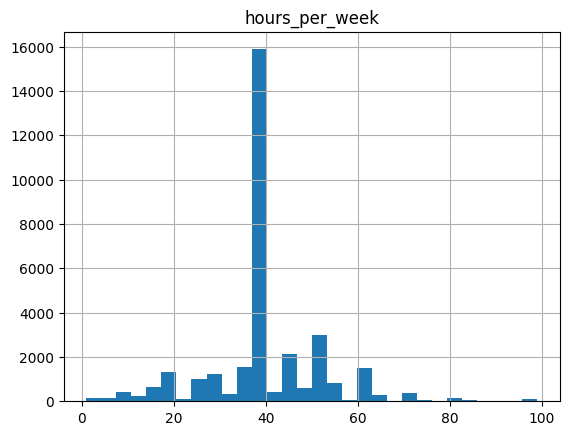

In [19]:
import matplotlib.pyplot as plt

numer = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]

for n in numer:
    df[n].hist(bins=30)
    plt.title(n)
    plt.show()

## Histograms

The histograms confirm that the numerical variables follow very different types of distributions.

- `age` is concentrated mostly between about 20 and 50, then declines gradually at higher ages.
- `education_num` takes a limited set of integer values, which is expected because it is an ordinal encoded variable rather than a continuous measurement.
- `hours_per_week` shows a very strong peak around 40 hours, with smaller groups at lower and higher values.
- `capital_gain` and `capital_loss` are highly right-skewed, with most observations concentrated at zero and a small number of large positive values.
- `fnlwgt` also appears unevenly distributed and is less directly interpretable than the other numerical variables.

Overall, the histograms suggest that the numerical features are not normally distributed, and some of them are strongly skewed. This is important to keep in mind when selecting preprocessing steps and evaluating whether synthetic data preserves the original feature distributions.

In [ ]:
for n in numer:
    df.boxplot(n)
    plt.title(n)
    plt.show()

## Boxplots

The boxplots support the same main conclusions from the histograms and make the spread and outliers more visible.

- `age` and `hours_per_week` show moderate spread, with visible outliers, especially at higher values.
- `education_num` has a compact range, which is consistent with its ordinal structure.
- `capital_gain` and `capital_loss` contain many extreme values relative to the bulk of the data, reflecting their strong skewness and concentration at zero.
- `fnlwgt` shows a wide spread and many high-value outliers.

These boxplots indicate that several numerical variables contain outliers or highly asymmetric distributions. This does not necessarily mean that the values are incorrect, but it does mean that the data is heterogeneous and should be handled carefully during preprocessing and synthetic data evaluation.

In [ ]:
categ_bar = ["income", "sex", "race", "workclass", "education", "marital_status", "occupation"]

for cat in categ_bar:
    df[cat].value_counts(dropna=False).plot(kind="bar")
    plt.title(cat)
    plt.show()

df["native_country"].value_counts(dropna=False).head(10).plot(kind="bar")
plt.title("native_country (top 10)")
plt.show()

## Bar charts

The bar charts make the imbalance patterns in the categorical variables easier to see.

- The `income` chart confirms that the target variable is imbalanced, with the `<=50K` class clearly dominating the `>50K` class.
- The `sex` chart shows that the dataset contains substantially more `Male` than `Female` records.
- The `race` chart is strongly dominated by the `White` category, while the remaining groups are much smaller.
- The `workclass` chart shows that `Private` is by far the largest category. Missing values exist in this feature, but they are not visible in the chart because `value_counts()` drops missing values by default.
- The `education` chart shows that a few education levels, especially `HS-grad`, `Some-college`, and `Bachelors`, account for a large share of the observations.
- The `marital_status` and `occupation` charts also reveal uneven category distributions, with a few dominant groups and several much smaller ones.
- The top-10 `native_country` chart confirms that `United-States` overwhelmingly dominates this variable.

These patterns are important because synthetic data generators may reproduce these imbalances very well for large groups while performing worse on small or underrepresented categories.

In [20]:
df[["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]].corr()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education_num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital_gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital_loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours_per_week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


## Correlation

The correlation matrix shows that the numerical variables in the Adult dataset are only **weakly correlated** with each other.

In [23]:
for c in ["workclass", "education", "marital_status", "occupation", "relationship", "race", "native_country"]:
    rare = df[c].value_counts(dropna=False)
    print(f"{rare[rare < 100]}\n")

workclass
Without-pay     14
Never-worked     7
Name: count, dtype: int64

education
Preschool    51
Name: count, dtype: int64

marital_status
Married-AF-spouse    23
Name: count, dtype: int64

occupation
Armed-Forces    9
Name: count, dtype: int64

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)

native_country
Cuba                          95
England                       90
Jamaica                       81
South                         80
China                         75
Italy                         73
Dominican-Republic            70
Vietnam                       67
Guatemala                     64
Japan                         62
Poland                        60
Columbia                      59
Taiwan                        51
Haiti                         44
Iran                          43
Portugal                      37
Nicaragua                     34
Peru                          31
France                        29
Greece                        

## Rare categories

Several categorical columns contain rare categories with very small numbers of observations.

This is especially important in variables such as `workclass`, `marital_status`, `race`, and `native_country`, where some groups appear only a few times compared with the dominant categories. Rare categories may be difficult for synthetic data generation methods to model accurately, and they may also be underrepresented or distorted in the generated data.

These low-frequency groups should therefore be noted during preprocessing and later evaluation, especially when checking whether minority categories are preserved realistically.

## Initial preprocessing considerations

Based on this EDA, the main preprocessing issues are:
- handling missing values in `workclass`, `occupation`, and `native_country` if needed
- deciding how to treat duplicate rows
- encoding categorical variables appropriately for baseline method(s)
- paying attention to strong class and group imbalance in `income`, `sex`, `race`, and `native_country`
- monitoring highly skewed numerical variables such as `capital_gain` and `capital_loss`